# 연관 분석 요약본

## 1. 연관 분석이란?

### 1-1. 연관 분석의 정의

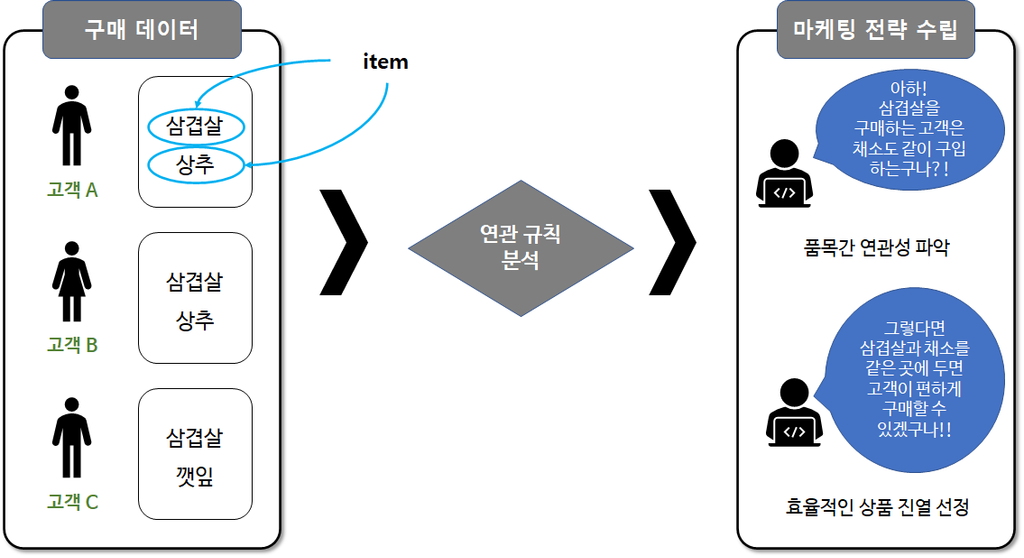

- 상품이나 서비스를 구매하는 등 일련의 거래나 사건 안에 존재하는 항목 간의 일정한 연관 규칙을 발견하는 분석
- 정답값이 별도로 존재하지 않기에 비지도 학습에 해당

### 1-2. 연관규칙 분석

**1) 연관규칙의 형태**
- A를 구매하였을 때, B 또한 구매할 것이다’와 같이 if-then 의 형식을 띄고, A→B으로 표현됨
   - **조건절(Antecedent):** '만일 ~라면'에 해당하는 부분
   - **결과절(Consequent):** 그 뒷부분에 해당하는 내용
   - **아이템 집합(Item set):** 조건절 또는 결과절을 구성하는 아이템들의 집합

*아이템 집합은 여러 개 아이템이 들어가도 되지만 상호 배반(mutually exclusive)이어야 함*

**2) 연관규칙 주의점**
- 연관규칙으로는 상관관계를 파악할 뿐이지 인과관계는 알 수 없음
   - 실험이 아닌 관찰 데이터이기 때문에 A를 사게 한 원인이 통제되지 않음. (숨겨진 공통 원인 존재 가능)
   - 방향성은 수학적 비율일 뿐, 즉 A → B는 “A가 원인이다”가 아니라 "A 샀을 때 B 산 비율"이 높은 것 뿐
   - 상관관계 ≠ 인과관계

## 2. 주요 개념

### 2-1. (적절한) 연관규칙의 조건

- 두 품목(품목 A와 B)이 함께 구매한 경우의 수가 일정 수준 이상이어야 한다. > **일정 이상의 지지도**
- 품목 A를 포함하는 거래 중 품목 B를 구입하는 경우의 수가 일정 수준 이상이어야 한다. > **일정 이상의 신뢰도**

**1) 지지도 (Support)**
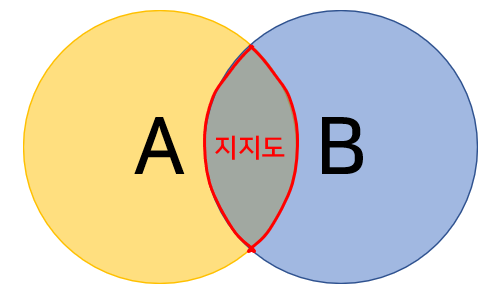
- 전체 거래항목 중 품목 A와 품목 B가 동시에 포함하는 거래의 비율
> 즉, ‘이 규칙이 현실에서 의미 있는가?'를 판단하는 가장 1차적인 기준

**2) 신뢰도 (Confidence)**
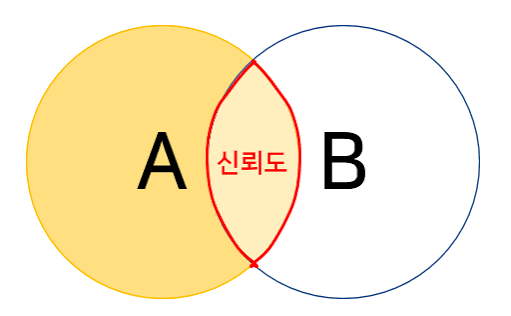
- 품목 A를 포함하는 거래 수 중 품목 A와 품목 B가 동시에 포함하는 거래의 비율
> A가 일어났을 때, B도 일어날 것이라고 얼마나 확신할 수 있는가?

### 2-2. 연관 분석의 평가 측도

- 품목 A가 주어지지 않았을 때의 품목 B의 확률 대비, 품목 A가 주어졌을 때의 품목 B의 확률의 증가 비율 > **향상도**

**1) 향상도(Lift)**
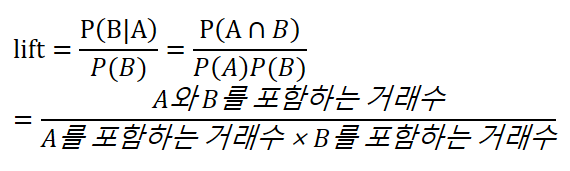

**i) 독립일 때 기대값**

- 확률에서 사건 A와 B가 독립이라면:
  - $P(A \cap B) = P(A) \cdot P(B)$
  - 즉, A를 샀다는 사실이 B를 살 확률에 영향을 주지 않는다는 뜻
  - 향상도는 1이 됨

$$
\text{향상도}
=
\frac{P(A \cap B)}{P(A)\cdot P(B)}
=
\frac{P(A)\cdot P(B)}{P(A)\cdot P(B)}
=
1
$$

- 확률에서 사건 A와 B가 독립이 아니라면:
  - $P(A \cap B) = P(A)\cdot P(B \mid A) = P(B)\cdot P(A \mid B)$
  - 즉, A를 샀다는 사실이 B를 살 확률에 영향을 주거나, B를 샀다는 사실이 A를 살 확률에 영향을 준다는 뜻
  - 실제로 관측한 $P(A \cap B)$에 따라 향상도는 1보다 크거나, 1보다 작음

**ii) 실제 동시 발생 확률**

- 우리가 실제로 관측한 $P(A \cap B)$가,
- A와 B가 함께 등장할 확률의 기대값 $P(A)\cdot P(B)$보다
  - 크면 → 양의 연관성 (A 산 사람은 B도 잘 삼)
  - 작으면 → 음의 연관성 (A 산 사람은 B 잘 안 삼)


## 3. 연관 분석 알고리즘

### 3-1. Apriori 알고리즘
**1) 배경**
- 연관 규칙을 찾기 위해 가능한 모든 조합을 시도하는 것은 매우 비효율적
  - 가능한 모든 조합: A(선행조건) → B(결과조건) 로 표현되도록 하는 모든 경우의 수
  - 이때 A, B는 단일 품목이 아니라 여러 품목으로 구성된 복합 조건이 될 수도 있음
- 상품의 개수가 많아질수록 조합의 수가 기하급수적으로 증가

**2) Apriori 알고리즘 소개**
- (개념) 상위 조합에서부터 차례로 스캔하면서 특정 조합이 자주 발생하지 않는다면 이의 결과물로 탄생한 후속 조합들까지 모두 후보에서 배제하는 방식의 알고리즘
- (장점) Apriori 알고리즘을 활용하면 하나의 조합만 검사하고도 이에서 파생된 다른 조합들까지 후보에서 배제할 수 있게 되므로 시간과 연산량을 효과적으로 줄일 수 있음

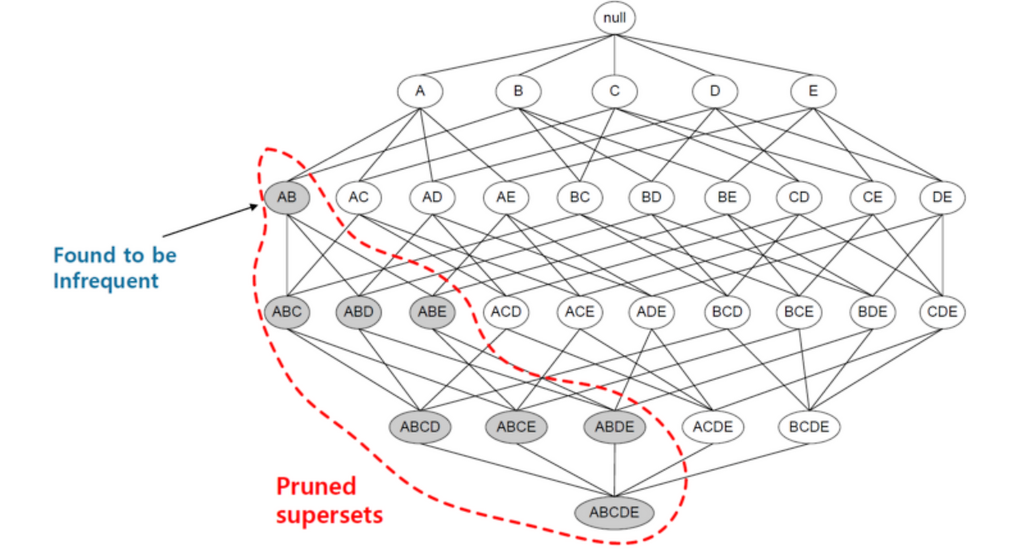

**3) Apriori 알고리즘 프로세스**

> 빈발 항목 집합을 찾고 → 단계적으로 조합을 생성하고 필터링

- 빈발 항목 집합: 일정한 최소 지지도를 넘는 항목들의 조합

i) 단일 항목 집합 생성

1. 모든 개별 상품에 대해 지지도를 계산한
2. 최소 지지도를 넘는 항목들만 다음 단계로 넘김

ii) 2개 항목 집합 생성

1. 1단계에서 선별된 상품들로 2개 항목의 조합 만듦
2. 이 조합에 대해 지지도를 계산하고 최소 지지도를 넘지 않는 조합 제거

iii) 더 큰 항목 집합 생성

1. 이전 단계에서 남은 조합들을 바탕으로 3개 이상의 항목으로 구성된 조합 만듦
2. 지지도를 계산하고 최소 지지도를 넘지 않는 조합 제거
3. 더 이상 조합을 생성할 수 없을 때까지 과정 반복

iv) 최종 빈발 항목 집합 선정

1. 마지막으로 남은 빈발 항목 집합들을 바탕으로 연관 규칙을 생성
2. 각 규칙에 대해 지지도, 신뢰도, 향상도를 계산하여 가장 유용한 규칙 선택

**4) Apriori 알고리즘의 장단점**

- 장점
   - 수많은 상품 연관 구매 패턴 발견
   - 원리가 간단하고, 이해 및 분석이 용이함

- 단점
   - 여전히 데이터가 커질수록 속도가 느려짐

### 3-2. FP Growth 알고리즘

> Apriori의 연산 속도 문제를 해결할 수 있게 자료구조를 잘 이용한 알고리즘

**1) 배경**
- Apriori 알고리즘은 여전히 데이터가 커질수록 속도가 느려지는 단점 존재
  - 각 단계에서 데이터를 다시 스캔해야 하기 때문

**2) FP-Growth 알고리즘 소개**
- 빈발 품목 집합을 효율적으로 찾아냄
- FP-Tree라는 구조를 이용하여 Apriori를 효과적으로 구현
- Tree, Array, Linked_List를 합쳐놓은 구조

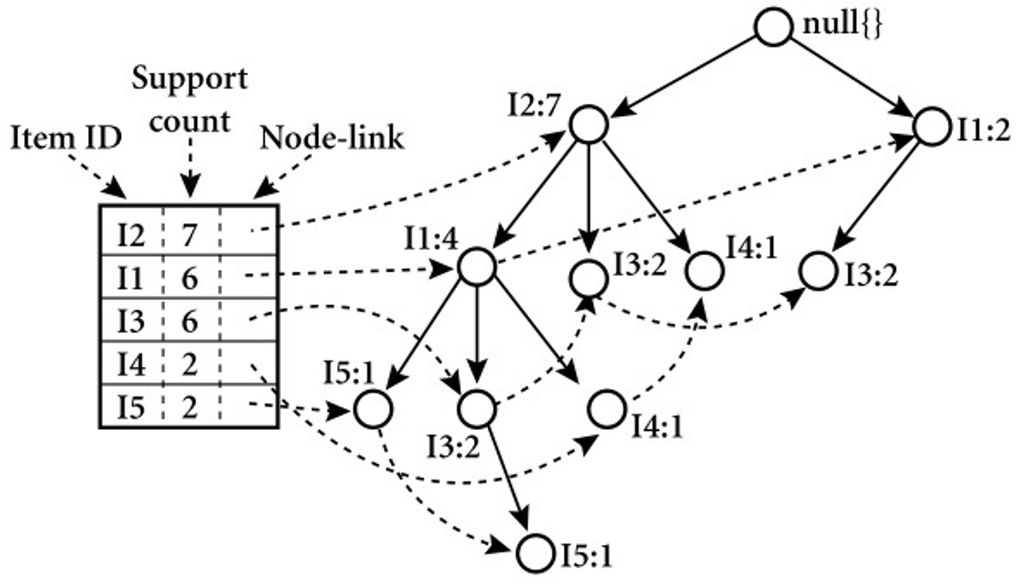

- 모든 거래를 확인해 각 아이템마다 지지도를 계산하고, 최소 지지도 이상의 아이템만 선택
  - 모든 거래에서 빈도가 높은 아이템 순서대로 순서를 정렬
  - 부모 노드를 중심으로 거래를 자식 노드로 추가해주며 tree를 생성
  - 새로운 아이템이 나올 경우 부모노드부터 시작하고, 그렇지 않으면 기존의 노드에서 확장
  - 위의 과정을 모든 거래에 대해 반복하여 FP Tree를 만들고 최소 지지도 이상의 패턴만 추출

**3) FP-Growth 알고리즘 프로세스**

- 모든 항목의 빈도를 계산한 후, 최소 지지도 이상인 항목만을 남김

i) 데이터셋 확인

ii) 빈도순 재정렬

- 남은 항목들을 각 거래별로 빈도순으로 재정렬
- 거래 데이터에서 가장 자주 구매된 항목이 먼저 오도록 재정렬
> f-list

iii) FP-트리 생성

- 재정렬된 데이터를 바탕으로 FP-트리 생성
- 이 트리는 각 거래를 노드로 표현
- 동일한 항목은 기존 노드에 연결해 빈도를 증가시키고, 새로운 항목은 새로운 노드로 추가

> dataset 안의 모든 itemset에 대해 tree를 만들면 최종적으로 FP-tree를 얻을 수 있음

iv) 빈발 항목 집합 추출

- FP-트리를 바탕으로 특정 항목을 기준으로 부분 트리를 만들어 빈발 항목 집합 추출
- 이 부분 트리에서는 기준이 된 항목과 연관된 빈발 항목 집합을 빠르게 도출할 수 있음

vi) 연관 규칙 도출

- FP-트리에서 도출된 빈발 항목 집합을 바탕으로 연관 규칙을 만듦
- 각 규칙에 대해 지지도(Support), 신뢰도(Confidence), 향상도(Lift) 등의 지표를 계산해 가장 유용한 규칙 선택

**4) FP-Growth 알고리즘의 장단점**

- 장점
   - 데이터를 두 번만 스캔하는 Tree 구조이기 때문에 Apriori보다 훨씬 빠름 
   - 후보 Itemset을 생성할 필요 없이 Tree만 구성하면 끝

- 단점
   - 대용량 데이터셋에서 메모리를 효율적으로 사용하지 않음
   - Apriori에 비해 설계하기 어렵고, 지지도의 계산은 무조건 FP-Tree가 만들어져야 가능